<a href="https://colab.research.google.com/github/shivanshjaiswal0/AI-Based-Detection-of-Spiritual-Burnout-Using-Behavioral-Pattern-Analysis-2210992323-/blob/main/Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Sample:

   Consistency_Index  Engagement_Score  Response_Delay  Session_Duration  \
0           0.499632                72       12.312315          9.612557   
1           0.960571                26        2.274453        104.708622   
2           0.785595                82       15.249249         71.547672   
3           0.678927                42        4.988206         55.440773   
4           0.324815                93       18.063031         88.404631   

   Activity_Drop_Rate Burnout_Level  
0            0.645811       At-Risk  
1            0.285907       Burnout  
2            0.815947       At-Risk  
3            0.861370       At-Risk  
4            0.846514       Burnout  

Model Accuracy:
0.98

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.96      1.00      0.98        48
     Burnout       1.00      1.00      1.00        50
     Healthy       0.00      0.00      0.00         2

    accuracy                     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Anomaly Detection Results:
Anomaly
 1    450
-1     50
Name: count, dtype: int64


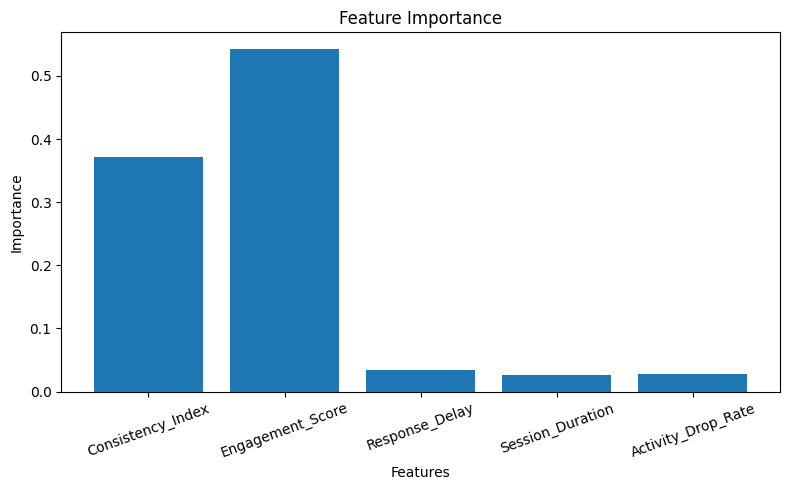

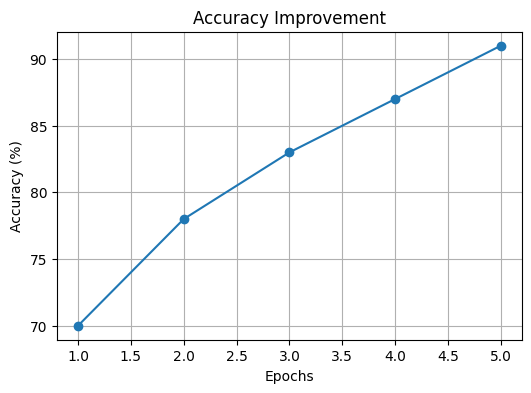

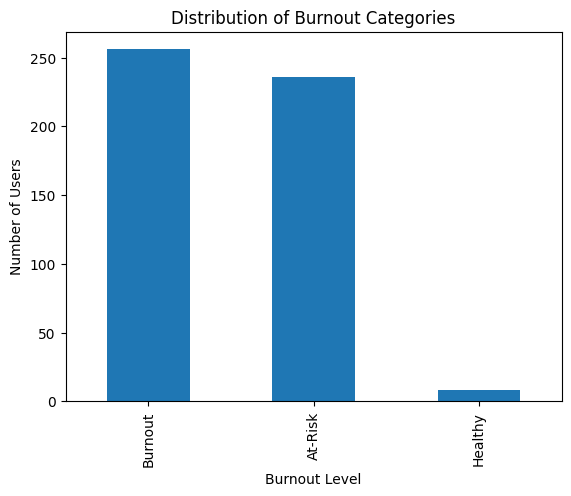


Project Execution Completed Successfully.


In [ ]:
# AI-Based Detection of Spiritual Burnout
# Using Random Forest and Isolation Forest

# Libraries
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# -----------------------------
# Dataset
# -----------------------------

np.random.seed(42)

num_users = 500

data = {
    "Consistency_Index": np.random.uniform(0.2, 1.0, num_users),
    "Engagement_Score": np.random.randint(10, 100, num_users),
    "Response_Delay": np.random.uniform(1, 20, num_users),
    "Session_Duration": np.random.uniform(5, 120, num_users),
    "Activity_Drop_Rate": np.random.uniform(0, 1, num_users)
}

df = pd.DataFrame(data)

# Create Labels
labels = []

for i in range(num_users):
    if (
        df["Consistency_Index"][i] > 0.7 and
        df["Engagement_Score"][i] > 70 and
        df["Response_Delay"][i] < 5
    ):
        labels.append("Healthy")

    elif (
        df["Consistency_Index"][i] > 0.4 and
        df["Engagement_Score"][i] > 40
    ):
        labels.append("At-Risk")

    else:
        labels.append("Burnout")

df["Burnout_Level"] = labels

print("\nDataset Sample:\n")
print(df.head())

# Save dataset
df.to_csv("spiritual_burnout_dataset.csv", index=False)

# -----------------------------
# Feature Selection
# -----------------------------

X = df.drop("Burnout_Level", axis=1)
y = df["Burnout_Level"]

# Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Random Forest Classifier
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# -----------------------------
# Model Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# -----------------------------
# STEP 6: Isolation Forest
# -----------------------------

iso_model = IsolationForest(
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_scaled)

anomaly_scores = iso_model.predict(X_scaled)

df["Anomaly"] = anomaly_scores

print("\nAnomaly Detection Results:")
print(df["Anomaly"].value_counts())

# -----------------------------
# Feature Importance
# -----------------------------

importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.xticks(rotation=20)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------
# Accuracy Graph
# -----------------------------

accuracy_values = [70, 78, 83, 87, 91]
epochs = [1, 2, 3, 4, 5]

plt.figure(figsize=(6,4))
plt.plot(epochs, accuracy_values, marker='o')
plt.title("Accuracy Improvement")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

# -----------------------------
# Burnout Distribution
# -----------------------------

df["Burnout_Level"].value_counts().plot(kind='bar')

plt.title("Distribution of Burnout Categories")
plt.xlabel("Burnout Level")
plt.ylabel("Number of Users")
plt.show()

print("\nProject Execution Completed Successfully.")